# TP 1 | Séries temporelles avec pandas et statsmodels

**Dataset :** [Airline Passengers](https://www.kaggle.com/datasets/erogluegemen/airline-passengers) | nombre mensuel de passagers aériens internationaux (en milliers), de janvier 1949 à décembre 1960. Série classique de Box & Jenkins.

| # | Tâche |
|---|-------|
| 1 | Importer le dataset AirPassengers |
| 2 | Afficher les 5 premières lignes |
| 3 | Convertir la colonne date en index temporel |
| 4 | Visualiser la série |
| 5 | Calculer et tracer une moyenne mobile sur 12 mois |
| 6 | Décomposer la série (tendance, saisonnalité, résidus) |

## 0. Configuration

Dépendances : `pandas`, `matplotlib`, `statsmodels`, `kagglehub`.

In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams["figure.dpi"] = 100
print(f"pandas {pd.__version__}")

pandas 3.0.6


---
## 1. Importer le dataset

In [2]:
path = kagglehub.dataset_download("erogluegemen/airline-passengers")
CSV = Path(path) / "airline-passengers.csv"

df = pd.read_csv(CSV)
print(f"Forme : {df.shape} -> {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(df.dtypes)

Forme : (144, 2) -> 144 lignes, 2 colonnes
month                 str
total_passengers    int64
dtype: object


La colonne `month` est lue comme du **texte** (`object`) : pandas ne sait pas encore que ce sont des dates.

---
## 2. Afficher les 5 premières lignes

In [3]:
df.head()

,month,total_passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df.describe()

,total_passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


144 observations mensuelles (12 ans x 12 mois), de 104 000 à 622 000 passagers par mois.

---
## 3. Convertir la date en index temporel

- `pd.to_datetime` transforme le texte `"1949-01"` en date (`1949-01-01`).
- `set_index` en fait l'**index** du DataFrame : chaque valeur est repérée par sa date, ce qui permet de sélectionner par période, de rééchantillonner ou de calculer des moyennes mobiles.
- `asfreq("MS")` déclare la fréquence : une observation au début de chaque mois (*Month Start*). statsmodels l'utilise pour connaître la période de la saisonnalité.

In [5]:
df["month"] = pd.to_datetime(df["month"], format="%Y-%m")
ts = df.set_index("month")["total_passengers"].asfreq("MS")

print("Type de l'index :", type(ts.index).__name__)
print("Fréquence       :", ts.index.freqstr)
print("Période         :", ts.index.min().date(), "->", ts.index.max().date())
print("Valeurs manquantes :", ts.isna().sum())
ts.head()

Type de l'index : DatetimeIndex
Fréquence       : MS
Période         : 1949-01-01 -> 1960-12-01
Valeurs manquantes : 0


month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Freq: MS, Name: total_passengers, dtype: int64

Grâce à l'index temporel, on peut sélectionner directement par date :

In [6]:
print("Année 1955 :")
print(ts.loc["1955"].to_string())
print(f"\nTotal par année (extrait) :\n{ts.resample('YS').sum().head(3).to_string()}")

Année 1955 :
month
1955-01-01    242
1955-02-01    233
1955-03-01    267
1955-04-01    269
1955-05-01    270
1955-06-01    315
1955-07-01    364
1955-08-01    347
1955-09-01    312
1955-10-01    274
1955-11-01    237
1955-12-01    278
Freq: MS

Total par année (extrait) :
month
1949-01-01    1520
1950-01-01    1676
1951-01-01    2042
Freq: YS-JAN


---
## 4. Visualiser la série

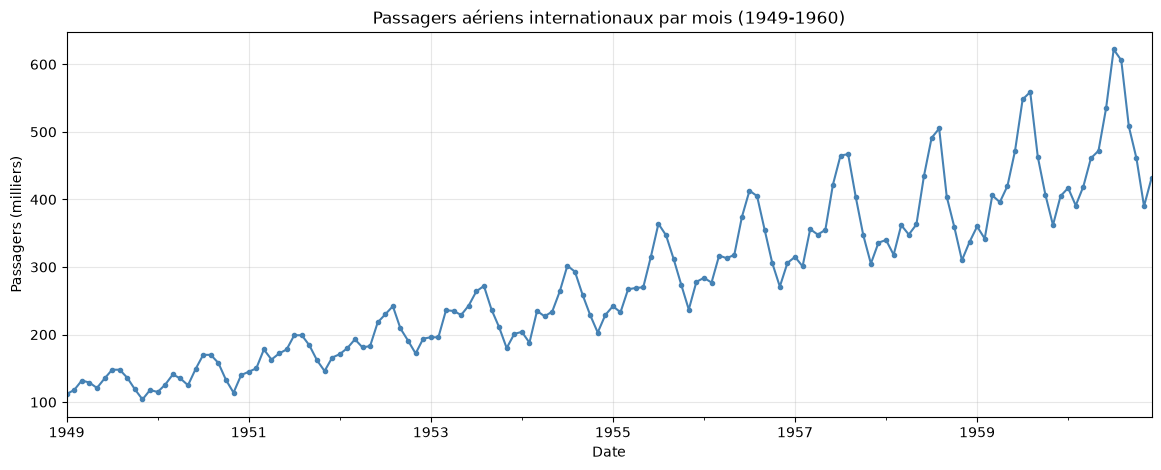

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ts.plot(ax=ax, color="steelblue", marker="o", markersize=3)
ax.set_title("Passagers aériens internationaux par mois (1949-1960)")
ax.set_xlabel("Date")
ax.set_ylabel("Passagers (milliers)")
ax.grid(alpha=0.3)
plt.show()

Superposition des années pour mettre en évidence le motif saisonnier :

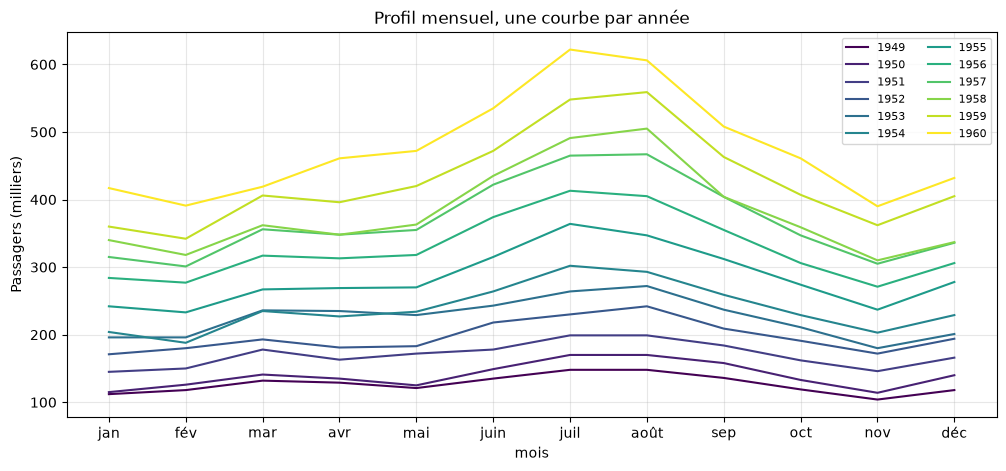

In [8]:
by_year = ts.to_frame("passagers")
by_year["année"] = by_year.index.year
by_year["mois"] = by_year.index.month
pivot = by_year.pivot(index="mois", columns="année", values="passagers")

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot(ax=ax, cmap="viridis")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["jan", "fév", "mar", "avr", "mai", "juin", "juil", "août", "sep", "oct", "nov", "déc"])
ax.set_title("Profil mensuel, une courbe par année")
ax.set_ylabel("Passagers (milliers)")
ax.legend(ncol=2, fontsize=8)
ax.grid(alpha=0.3)
plt.show()

**Observations :**
- **Tendance** croissante : le trafic annuel est multiplié par 3,8 en 12 ans (1 520 000 passagers en 1949, 5 714 000 en 1960).
- **Saisonnalité** annuelle : pic chaque été (juillet-août), creux en novembre et en début d'année.
- L'**amplitude** des variations saisonnières **augmente** avec le niveau de la série : les écarts sont proportionnels à la tendance. C'est le signe d'une saisonnalité **multiplicative** (utile pour la question 6).

---
## 5. Moyenne mobile sur 12 mois

La moyenne mobile remplace chaque valeur par la moyenne des 12 derniers mois. Une fenêtre de 12 mois contient exactement **un cycle saisonnier complet** : les pics et creux se compensent, il ne reste que la **tendance**.

`rolling(12).mean()` renvoie `NaN` pour les 11 premiers mois (pas encore 12 valeurs disponibles).

In [9]:
rolling_mean = ts.rolling(window=12).mean()
rolling_std = ts.rolling(window=12).std()

print(rolling_mean.head(13).to_string())

month
1949-01-01           NaN
1949-02-01           NaN
1949-03-01           NaN
1949-04-01           NaN
1949-05-01           NaN
1949-06-01           NaN
1949-07-01           NaN
1949-08-01           NaN
1949-09-01           NaN
1949-10-01           NaN
1949-11-01           NaN
1949-12-01    126.666667
1950-01-01    126.916667
Freq: MS


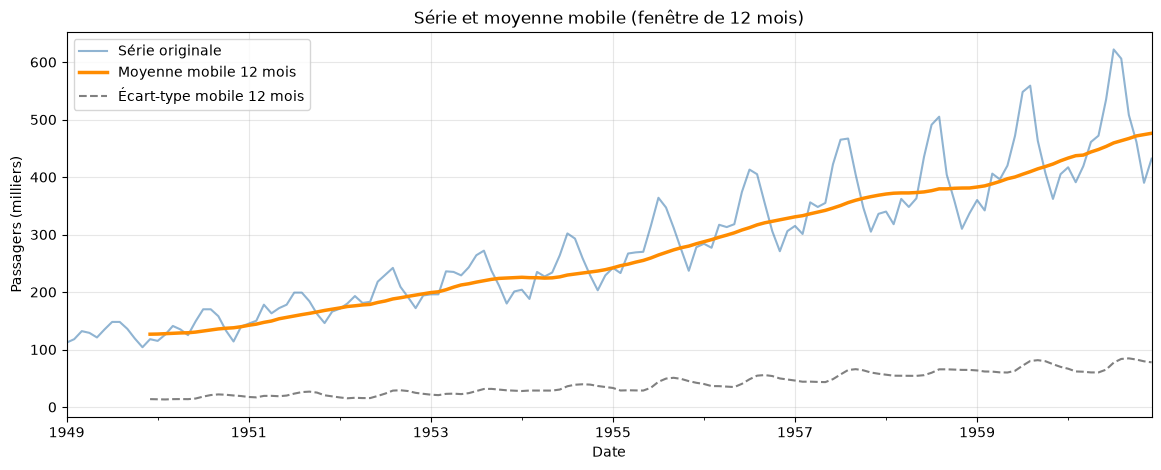

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ts.plot(ax=ax, color="steelblue", alpha=0.6, label="Série originale")
rolling_mean.plot(ax=ax, color="darkorange", linewidth=2.5, label="Moyenne mobile 12 mois")
rolling_std.plot(ax=ax, color="gray", linestyle="--", label="Écart-type mobile 12 mois")
ax.set_title("Série et moyenne mobile (fenêtre de 12 mois)")
ax.set_xlabel("Date")
ax.set_ylabel("Passagers (milliers)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**Lecture :**
- La moyenne mobile est **lisse** : la saisonnalité a disparu, il reste une tendance régulièrement croissante.
- L'écart-type mobile **augmente** lui aussi : la dispersion grandit avec le niveau. La série n'est donc **pas stationnaire**, ni en moyenne, ni en variance.
- La courbe est décalée : chaque point résume les 12 mois **précédents**. `rolling(12, center=True)` centrerait la fenêtre.

---
## 6. Décomposition de la série

`seasonal_decompose` sépare la série en trois composantes :

| Modèle | Formule | Quand l'utiliser |
|---|---|---|
| Additif | $y_t = T_t + S_t + R_t$ | amplitude saisonnière constante |
| Multiplicatif | $y_t = T_t \times S_t \times R_t$ | amplitude saisonnière proportionnelle au niveau |

- **Tendance** $T_t$ : moyenne mobile centrée sur 12 mois ;
- **Saisonnalité** $S_t$ : profil moyen de chaque mois, répété chaque année ;
- **Résidus** $R_t$ : ce qui reste, la partie irrégulière.

D'après la question 4, on choisit le modèle **multiplicatif**.

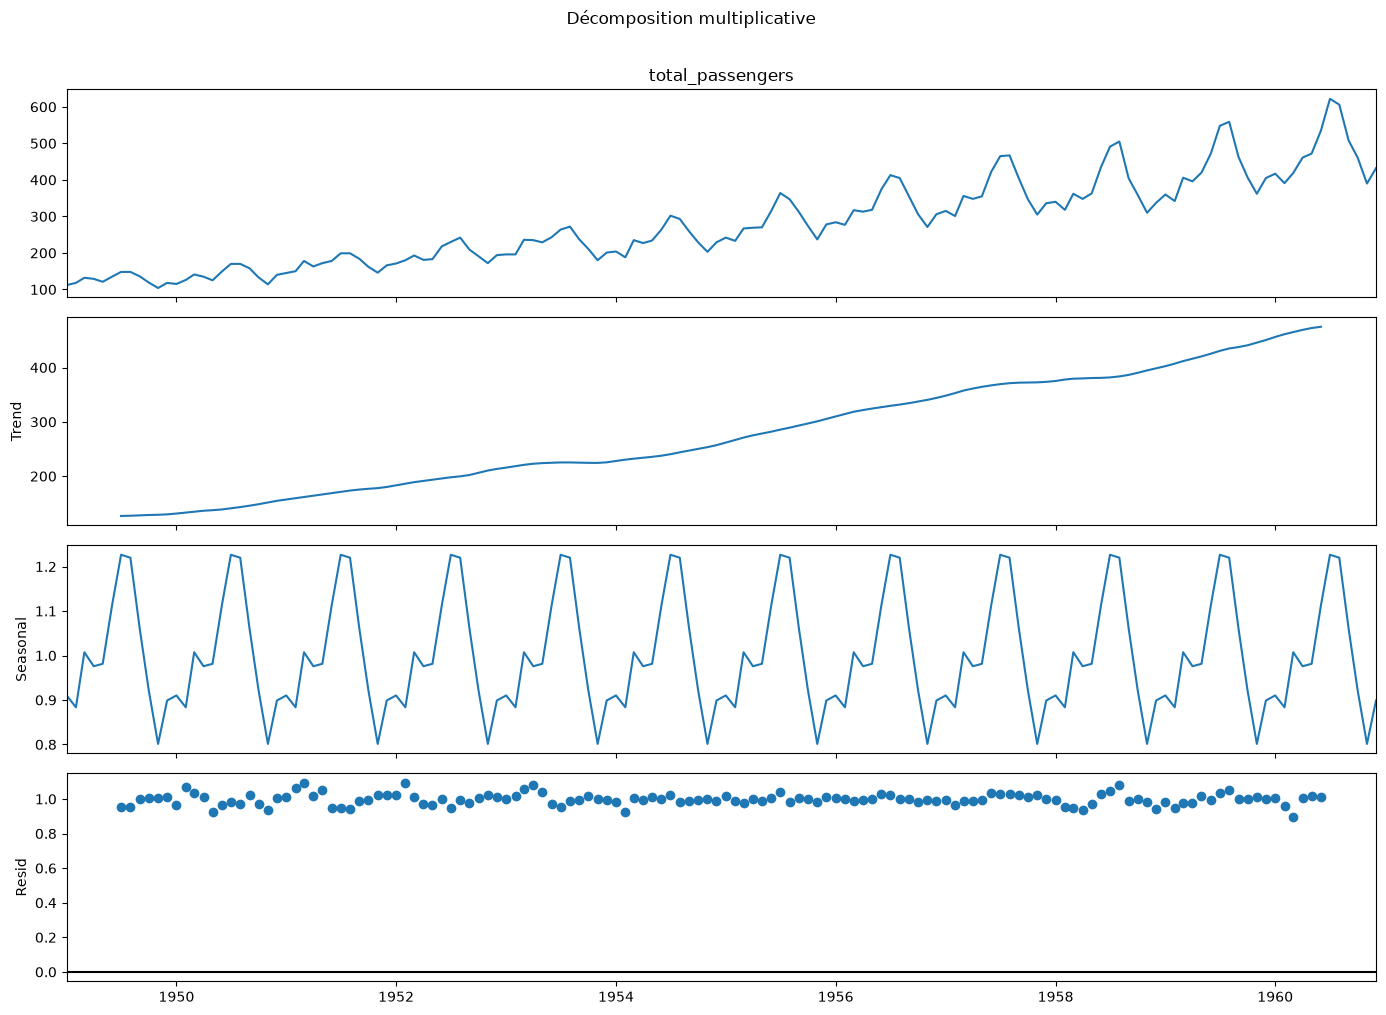

In [11]:
decomp = seasonal_decompose(ts, model="multiplicative", period=12)

fig = decomp.plot()
fig.set_size_inches(14, 10)
fig.suptitle("Décomposition multiplicative", y=1.01)
plt.tight_layout()
plt.show()

Coefficient saisonnier par mois :
jan     0.910
fév     0.884
mar     1.007
avr     0.976
mai     0.981
juin    1.113
juil    1.227
août    1.220
sep     1.060
oct     0.922
nov     0.801
déc     0.899


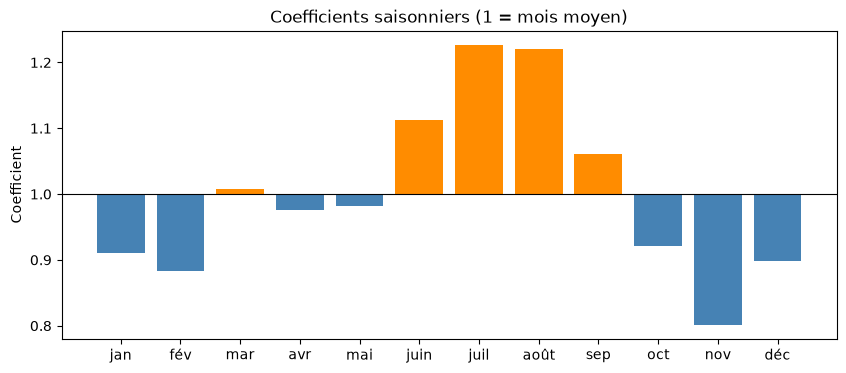

In [12]:
months = ["jan", "fév", "mar", "avr", "mai", "juin", "juil", "août", "sep", "oct", "nov", "déc"]
factors = decomp.seasonal.iloc[:12]
factors.index = months

print("Coefficient saisonnier par mois :")
print(factors.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(months, factors - 1, bottom=1, color=["darkorange" if f > 1 else "steelblue" for f in factors])
ax.axhline(1, color="black", linewidth=0.8)
ax.set_title("Coefficients saisonniers (1 = mois moyen)")
ax.set_ylabel("Coefficient")
plt.show()

**Lecture des composantes :**
- **Tendance** : croissance régulière, identique à la moyenne mobile de la question 5 (mais centrée). Elle n'est pas définie sur les 6 premiers et 6 derniers mois, faute de fenêtre complète.
- **Saisonnalité** : un coefficient de 1,23 en juillet signifie que ce mois est environ **23 % au-dessus** de la tendance ; novembre est environ **20 % en dessous**. Le même profil se répète chaque année.
- **Résidus** : centrés autour de 1, avec des écarts de quelques pourcents seulement : la tendance et la saisonnalité expliquent l'essentiel de la série.

### Comparaison avec le modèle additif

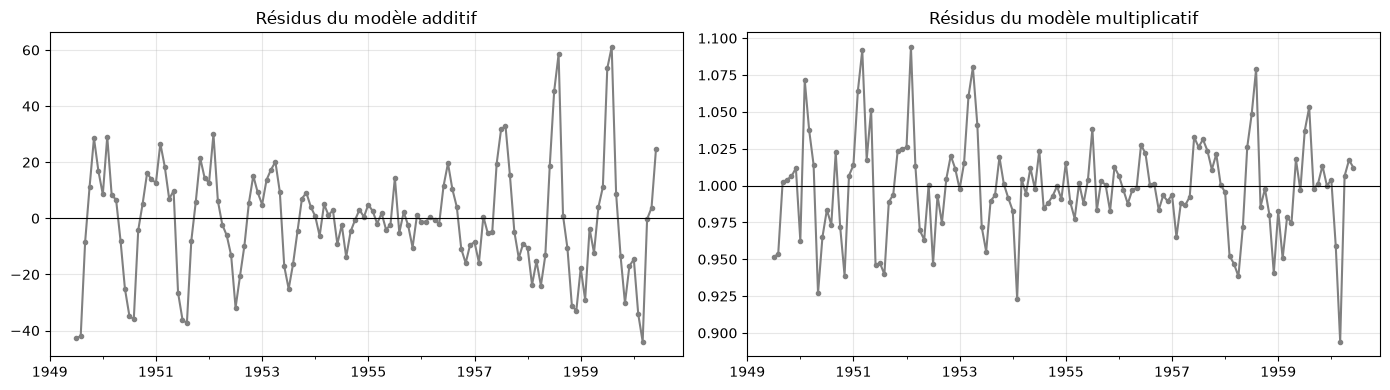

In [13]:
decomp_add = seasonal_decompose(ts, model="additive", period=12)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
decomp_add.resid.plot(ax=axes[0], color="gray", marker="o", markersize=3)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Résidus du modèle additif")
decomp.resid.plot(ax=axes[1], color="gray", marker="o", markersize=3)
axes[1].axhline(1, color="black", linewidth=0.8)
axes[1].set_title("Résidus du modèle multiplicatif")
for ax in axes:
    ax.set_xlabel("")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Le modèle **additif** applique la même amplitude saisonnière (en milliers de passagers) à toutes les années : elle est trop forte au début, quand le trafic est faible, et trop faible à la fin. Ses résidus gardent donc des **oscillations annuelles régulières**, grandes en début et en fin de période, faibles au milieu (vers 1955) : une partie de la saisonnalité n'a pas été capturée.

Le modèle **multiplicatif** adapte l'amplitude au niveau de la série : ses résidus sont plus irréguliers et ne représentent que quelques pourcents de la valeur. C'est le bon choix pour cette série.

---
## Conclusion

| Notion | À retenir |
|---|---|
| Index temporel | `pd.to_datetime` + `set_index` + `asfreq` : sélection par date, rééchantillonnage |
| Visualisation | révèle tendance, saisonnalité et évolution de l'amplitude |
| Moyenne mobile | fenêtre = période saisonnière (12 mois) : lisse la saisonnalité, isole la tendance |
| Décomposition | tendance + saisonnalité + résidus avec `seasonal_decompose` |
| Additif / multiplicatif | amplitude saisonnière constante / proportionnelle au niveau |
| AirPassengers | tendance croissante, pic en été, saisonnalité multiplicative, série non stationnaire |